In [1]:
import numpy as np
from astropy import units as u
from astropy.constants import m_e, h
from astropy.coordinates import Distance

from agnpy.spectra import PowerLaw
from agnpy.emission_regions import Blob
from agnpy.synchrotron import Synchrotron
from agnpy.compton import SynchrotronSelfCompton
from agnpy.time_evolution.time_evolution import TimeEvolution, synchrotron_loss, ssc_loss
from agnpy.utils.plot import plot_sed
from agnpy.bsm.liv import LIVdelay

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
# set the quantities defining the blob and the electron distribution
R_b = 1e16 * u.cm
V_b = 4 / 3 * np.pi * R_b ** 3
W_e = 1e48 * u.erg # total energy in electrons
z = Distance(1e27, unit=u.cm).z
delta_D = 10
Gamma = 10
B = 1 * u.G

# initial electron distribution
n_e_initial = PowerLaw.from_total_energy(
    W_e,
    V_b,
    p=2.8,
    gamma_min=1e2,
    gamma_max=1e7,
    mass=m_e,
)

In [3]:
# define the blob and the energy loss mechanism
blob = Blob(R_b, z, delta_D, Gamma, B, n_e=n_e_initial)
synch = SynchrotronSelfCompton(blob)


# define the blob and the energy loss mechanism for LIV
blob_liv = Blob(R_b, z, delta_D, Gamma, B, n_e=n_e_initial)
synch_liv = SynchrotronSelfCompton(blob_liv)

# define LIVdelay classes
nu_syn = np.logspace(21, 28, 100) * u.Hz
E_syn = nu_syn*h.to("GeV/Hz")

withliv = LIVdelay(lambda_liv=200*u.s/u.TeV, n_liv=1, nu_syn=nu_syn)

steps = 16
time_step = 10*u.min

min_time = 0
max_time = steps*time_step
time_obs_array = np.linspace(min_time, max_time, steps+1)

In [4]:
# calculate the array of time evoluted SEDs
time_evoluted_seds = []
for i in range(steps+1):
    time_evolution = TimeEvolution(blob_liv, time_step, ssc_loss(synch_liv))
    time_evolution_result = time_evolution.evaluate()
    time_evoluted_seds.append(synch_liv.sed_flux(nu_syn))

In [5]:
def interpolate_seds(t, nu_index):
    """Interpolates SEDs in between time frames
    """
    if (t < min_time):
        return 0. # Sets the SEDs for all times before the "start" equal to zero (not ideal)
    if (t >= max_time):
        return  time_evoluted_seds[-1][nu_index] # Similarly, sets the SEDs for all times after the last simulated value equals to the last simulated SED (not ideal either, but if the flux is small enough maybe ok)
    time_index = np.searchsorted(time_obs_array, t, side='right')
    slope = (time_evoluted_seds[time_index][nu_index]-time_evoluted_seds[time_index-1][nu_index]) / time_step
    return time_evoluted_seds[time_index-1][nu_index] + slope * (t-time_obs_array[time_index-1])

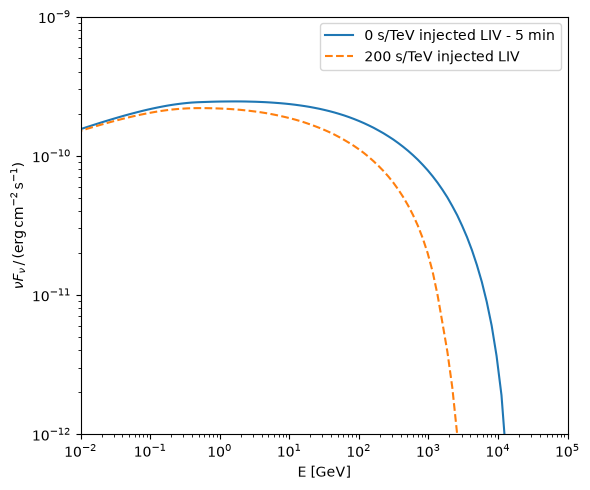

In [6]:
cmap = plt.get_cmap('viridis')

fig = plt.figure(figsize=(6,5))

time_obs = 5*u.min

# Compute the spectrum at the observation time for both cases
time_evolution = TimeEvolution(blob, time_obs, ssc_loss(synch))
time_evolution_result = time_evolution.evaluate()

time_evoluted_sed_liv = np.zeros(len(nu_syn))
for nu_index, nu in enumerate(nu_syn):
    time_obs_liv = time_obs + withliv.calculate_time_delay(nu*h.to("TeV s"))
    time_evoluted_sed_liv[nu_index] = interpolate_seds(time_obs_liv, nu_index).value


# Positive LIV
plot_sed(
    E_syn,
    synch.sed_flux(nu_syn),
    label="0 s/TeV injected LIV - {:.0f}".format(time_obs)
)
plt.plot(
    E_syn,
    time_evoluted_sed_liv,
    '--',
    label=r"200 s/TeV injected LIV"
)


plt.xscale('log')
plt.xlim([1e-2, 1e5]) # GeV
plt.xlabel('E [GeV]')

plt.yscale('log')
plt.ylabel(r"$\nu F_{\nu}\,/\,(\mathrm{erg}\,\mathrm{cm}^{-2}\,\mathrm{s}^{-1})$")
plt.ylim([1e-12, 1e-9])

plt.legend()

plt.tight_layout()
plt.show()